In [2]:
import numpy as np
np.acosh(1)

np.float64(0.0)

In [ ]:
import numpy as np

# Simple Q-learning example for a 2x2 grid world
# States: 0 (start), 1, 2, 3 (goal)
# Actions: 0 (up), 1 (down), 2 (left), 3 (right)



Trained Q-table:
[[2.69730000e-03 8.08424643e+00 1.59964391e+00 0.00000000e+00]
 [1.52751025e+00 1.49812622e+00 1.22332568e+00 8.99710481e+00]
 [2.43836418e+00 9.99973439e+00 2.99325130e+00 1.62743494e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]]


In [1]:
# 方法1：使用 %reload_ext
%reload_ext autoreload
%autoreload 2  
# 自动重新加载所有模块

import numpy as np
import matplotlib.pyplot as plt

import func

In [ ]:
class mono:
    def __init__(self,beta:float,a:float,b:float,c:list,k0:float,i=0,s=0):
        '''
        k0 initial capital\\
        a b demand function\\
        c cost list\\
        i innovation input\\
        s technology state code\\
        beta discount rate
        '''
        self.k0 = k0
        self.a = a
        self.b = b
        self.c = c
        self.k = k0
        self.i = i
        self.s = s
        self.beta = beta


    def demand_function(self,q):
        '''
        given total supply and return price
        '''
        return self.b-self.a*q
    
    def tech(self,s):
        '''
        transform state code into prob of progress, you can change different funcs here
        '''
        self.innovation = 0.1*s / (0.1*s+1)
        return self.innovation
     
    def revenue(self,q):
        '''
        give mono's output return revenue
        '''
        return self.demand_function(q)*q - self.c[self.s]*q
    
    def optimal(self):
        '''
        Find the optimal quantity for a given expansion level
        '''
        return func.maximize(self.revenue, 0, self.b/self.a)
    
    

# #  科技状态上限 产量上限
    
    def new_tech(self):
        p = self.tech(self.i)
        m = np.random.uniform(0,1)
        if m < p:
            self.s += 1
            self.i = 0
        if self.s >= len(self.c):
            self.s = len(self.c)-1
        return self.s
    
    def input_limit(self):
        level = self.optimal()[0]
        max = float(self.c[self.s]*level)
        return max
     
    def session(self,e):
        # e:expansion
        # s:state 三种科技状态
        if e>self.k:
            raise ValueError("Insufficient capital")        # 当每一个状态成为成本函数的时候每一个self.c后面要进行call
        

        # i:innovation e:expansion s:state k:captial at the beginning
        level = self.optimal()[0]
        max = float(self.c[self.s]*level)           
        if e > max:
            #print('surpass!')
            q = level
            e = max
            profit = self.optimal()[1]
        else:
            
            q = e / self.c[self.s]
            #print(q)
            profit = self.demand_function(q)*q - e
        return profit    

    def update(self,e):
        profit = self.session(e)
        if self.s < len(self.c)-1:
            #print('invest in tech')
            self.i += -e+self.k
            self.k = profit
        else:
            self.k = profit + self.k - e
        
        #print('summary: ')
        #print(f'Tech:{self.s},profit: {profit}, capital: {self.k},R&D:{self.i},Expansion:{e}')
        
        # 每一期应当选择将当期初始资本全部投入
        
        # i = -e+self.k
  
            


In [3]:
ie = mono(0.5, 1, 100, [20,15,10], 1000)


In [4]:
ie.update(10)

In [5]:
ie.update(10)

In [8]:
ie.input_limit

<bound method mono.input_limit of <__main__.mono object at 0x0000024B69F29A90>>

In [ ]:
func.maximize(ie.session,0,ie.input_limit())

In [6]:
def mono_simulate(alpha,gamma,epsilon,episodes,max_steps):    

#import numpy as np

    # Assuming ie is already defined, use its parameters
    num_states = len(ie.c)  # 3 states (s = 0,1,2)
    num_actions = 10  # Discretize actions into 10 levels for e
    #alpha = 0.1  # Learning rate
    #gamma = 0.9  # Discount factor
    #epsilon = 0.1  # Exploration rate
    #episodes = 1000  # Number of episodes
    #max_steps = 100  # Max steps per episode

    # Initialize Q-table
    Q = np.zeros((num_states, num_actions))
    action = np.zeros(max_steps)
    memo = np.zeros(max_steps)
    for episode in range(episodes):
        # Reset environment for each episode
        env = mono(0.5, 1, 100, [20, 15, 10], 1000)
        state = env.s
        done = False
        step = 0
        incre_memo = np.array([])
        incre_Q = np.zeros((num_states, num_actions))
        incre_action = np.array([])
        while not done and step < max_steps:
            # Compute possible e levels based on current k and input_limit
            max_e = min(env.k, env.input_limit())
            e_levels = np.linspace(1e-10, max_e, num_actions)
            state = env.new_tech()
            # Epsilon-greedy action selection
            if env.s == 2:
                action = 9
            elif np.random.rand() < epsilon:
                action = np.random.randint(num_actions)
            else:
                action = np.argmax(incre_Q[state])
            
            e = e_levels[action]
            
            # Take action: get reward and next state
            reward = env.session(e)
            incre_memo = np.append(incre_memo,reward)
            incre_action = np.append(incre_action, action)
        # Update environment
            env.update(e)
            if env.s == num_states - 1:
                next_state = [env.s,]
                incre_Q[state, action] += alpha * (reward + gamma * np.max(incre_Q[next_state[0]]) - incre_Q[state, action])
            else:
                next_state = [env.s,env.s+1]
                incre_Q[state, action] += alpha * (reward + gamma *env.innovation* np.max(incre_Q[next_state[1]]) - incre_Q[state, action]
                                            +gamma *(1-env.innovation)* np.max(incre_Q[next_state[0]]))
            # Update Q-table
            
            
        
            #env.s == num_states - 1 or
            # Check termination condition (e.g., max tech state or no capital)
            if env.k <= 0:
                print('no money!!')
                done = True
            
            step += 1
        memo = (episode/(1+episode))*memo + incre_memo/(episode+1)
        action = (episode/(1+episode))*action + incre_action/(episode+1)
        Q = (episode/(1+episode))*Q + incre_Q/(episode+1)
    #print("Trained Q-table:")
    #print(Q)
    return action,memo,Q

In [2]:
import matplotlib.pyplot as plt

In [9]:
np.linspace(0,1,10)

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

Trained Q-table
[[3.70403564e-11 2.35061728e-01 4.42469136e-01 4.44444444e-01
  1.65925926e+00 1.02716049e+00 8.53333333e-01 1.67308642e+00
  1.73827160e+00 2.22468571e+00]
 [4.62789445e-03 1.69559472e-01 5.91719108e-02 5.20471704e-01
  3.38094455e-01 1.04974943e+00 1.05934285e+00 3.07591677e+00
  5.31285953e+00 1.84941634e+01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 3.62716232e+03]]
Trained Q-table
[[2.60201782e-11 1.71259259e+00 1.86157620e+00 3.81344096e+00
  4.42469136e+00 4.10899498e+00 6.68444444e+00 6.96682947e+00
  6.00493827e+00 5.28015212e+00]
 [3.08656312e-02 7.17402080e-01 2.40305866e+00 2.03475104e+00
  2.72018320e+00 2.10082965e+00 3.80548357e+00 6.23096167e+00
  9.12800724e+00 1.19562087e+01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 7.80093154e+03]]
Trained Q-table
[[1.4560

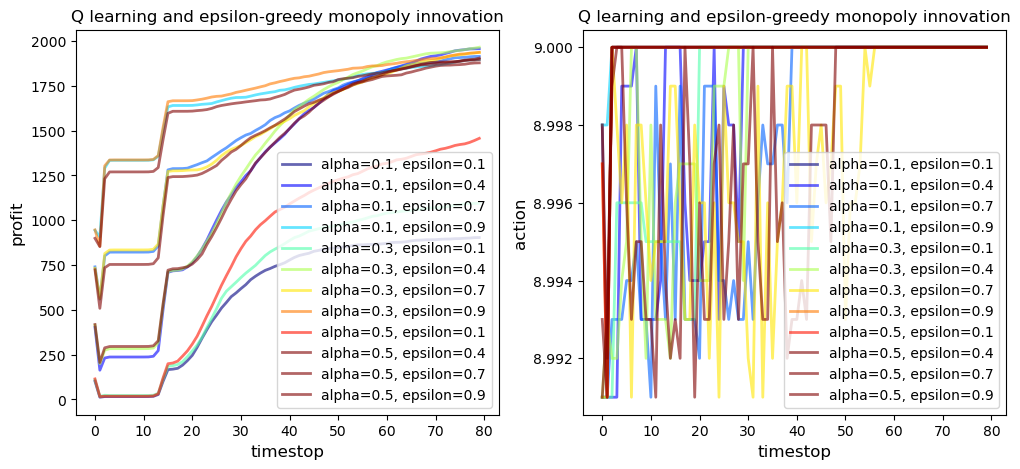

In [11]:
#                  alpha discount epsilon epidsodes max_steps

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
A = np.array([0.1,0.3,0.5])
E = np.array([0.1,0.4,0.7,0.9])
t = [_ for _ in range(80)]
combinations = np.array(np.meshgrid(A,E)).T.reshape([12,2])

for i,[alpha, epsilon] in enumerate(combinations):
    action,memo,Q = mono_simulate(alpha,0.9,epsilon,1000,80)
    print('Trained Q-table')
    print(Q)
    ax[0].plot(t,memo,color=plt.cm.jet(i/9), lw=2, alpha=0.6,label=f'alpha={alpha}, epsilon={epsilon}')
    ax[1].plot(t,action,color=plt.cm.jet(i/9), lw=2, alpha=0.6,label=f'alpha={alpha}, epsilon={epsilon}')
ax[0].legend()
ax[0].set_ylabel('profit', fontsize=12)
ax[0].set_xlabel('timestop', fontsize=12)
ax[0].set_title('Q learning and epsilon-greedy monopoly innovation')

ax[1].legend()
ax[1].set_ylabel('action', fontsize=12)
ax[1].set_xlabel('timestop', fontsize=12)
ax[1].set_title('Q learning and epsilon-greedy monopoly innovation')

plt.show()


In [19]:
Q_01 =np.array([
[1.71428572e-02, 8.73355478e+00, 1.76987654e+01, 2.53452292e+01,
        2.90408401e+01, 3.21194866e+01, 3.69777778e+01, 3.91742573e+01,
        4.81975309e+01, 3.56171429e+01],
       [1.53002044e-10, 5.06193605e+00, 1.00102210e+01, 1.31078332e+01,
        1.78804920e+01, 1.62894666e+01, 1.64697462e+01, 1.65639175e+01,
        1.79186265e+01, 3.03015160e+01]])

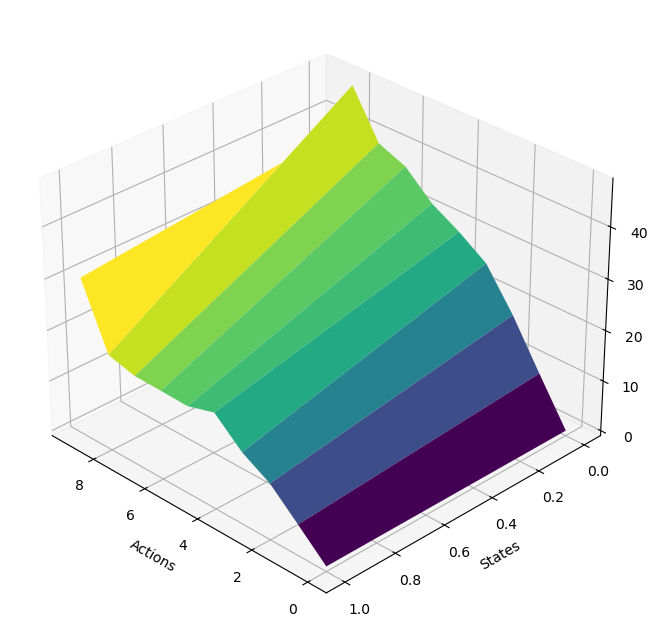

In [25]:
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Assuming Q is the 3x10 Q-table from mono_simulate
states = np.arange(Q_01.shape[0])  # 0, 1, 2
actions = np.arange(Q_01.shape[1])  # 0 to 9
X, Y = np.meshgrid(actions, states)

ax.plot_surface(X, Y, Q_01, cmap='viridis', edgecolor='none')
ax.set_xlabel('Actions')
ax.set_ylabel('States')
ax.set_zlabel('Q-values')
#ax.set_title('3D Surface Plot of Q-table')

ax.view_init(azim=135)
plt.show()

In [316]:
# Q-table initialization
Q = np.zeros((4, 4))

# Rewards: goal at state 3 gives +10, others 0
rewards = np.array([0, 0, 0, 10])

# Learning parameters
alpha = 0.1  # learning rate
gamma = 0.9  # discount factor
epsilon = 1  # exploration rate

# Simple transition function (deterministic for simplicity)
def get_next_state(state, action):
    if state == 0 and action == 1: return 1  # down
    if state == 1 and action == 3: return 2  # right
    if state == 2 and action == 1: return 3  # down
    return state  # stay otherwise

# Training loop (simplified)
for episode in range(100):
    state = 0
    while state != 3:
        if np.random.rand() < epsilon:
            action = np.random.randint(4)
        else:
            action = np.argmax(Q[state])
        next_state = get_next_state(state, action)
        reward = rewards[next_state]
        Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])
        state = next_state

print("Trained Q-table:")
print(Q)

Trained Q-table:
[[7.23057787 8.08424643 7.22821851 7.23667248]
 [8.07781379 8.05928656 8.07769262 8.99710481]
 [8.99864227 9.99973439 8.9961326  8.99851349]
 [0.         0.         0.         0.        ]]


290